# Code for the third figure of Section 5.6: Extra Capacity in the Score Space

In [4]:
!nvidia-smi

Mon Apr  6 19:00:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             52W /  400W |     548MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            mask = (torch.rand_like(tensor) > sparsity).float()  # Keeps (1 - sparsity)% weights
            tensor *= mask
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, extra_capacity=0, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        self.scores = nn.Parameter(torch.randn(out_features,math.ceil(in_features*(1+extra_capacity))))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(math.ceil(1+extra_capacity),out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.mode= "mask"
        self.k=k
    def forward(self, x):
      if self.mode!= "static":
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[0,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)
      else:
        return F.linear(x,self.weight)

    def toggle_mode(self, mode):
        self.mode = mode
        if mode=='classic':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(False)
        if mode=='mask':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(True)
        if mode=='hybrid':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(True)
        if mode=='static':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(False)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, k=0.5, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias, k=k, extra_capacity=extra_capacity), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    def toggle_mode(self, mode):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)
    def set_ks(self,ks):
        i=0
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k=ks[i]
                i+=1

Using cuda device


Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10



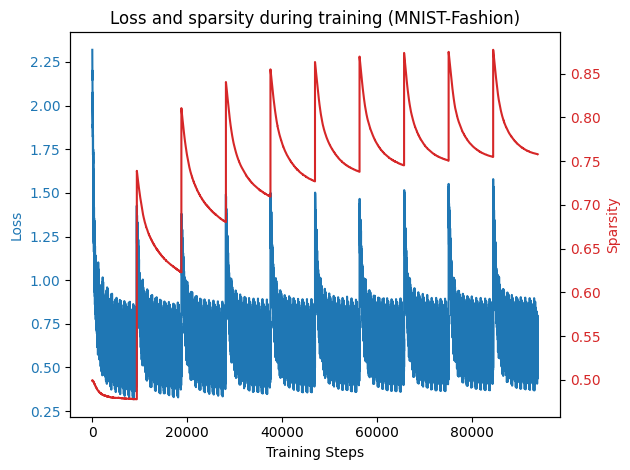

In [9]:
epochs = 10
runs=10
batch_size = 64
layer_sizes=[[28*28,256],[256,10]]

def get_effective_weight_sparsity(model):
    total_zeros = 0
    total_weights = 0

    for layer in model.layers:
        if isinstance(layer,LinearSubnet):
            mask = GetSubnet.apply(layer.scores.abs(), layer.k)[:, :layer.weight.shape[-1]]
            bmask = GetSubnet.apply(layer.bias_scores.abs(), layer.k)[0,:layer.bias.shape[-1]]
            total_zeros += (layer.weight.data*mask == 0).sum().item()+(layer.bias.data*bmask==0).sum().item()
            total_weights += layer.weight.numel()+layer.bias.numel()
    return total_zeros / total_weights if total_weights > 0 else 0.0

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()
losses = []
sparsity=[]

model = Network(layer_sizes, extra_capacity=1.0)
model.to(device)
optimizer = torch.optim.Adam(model.parameters())
for run in range(runs):
  optimizer = torch.optim.Adam(model.parameters())
  for t in range(epochs):
      print(f"Epoch {t+1}\n")
      model.train()
      for (X, y) in train_dataloader:
          X,y = X.to(device), y.to(device)
          optimizer.zero_grad()
          pred = model(X)
          loss = loss_fn(pred, y)
          losses.append(loss.item())
          sparsity.append(get_effective_weight_sparsity(model))
          loss.backward()
          optimizer.step()
  for layer in model.layers:
      if hasattr(layer, "scores") and hasattr(layer, "weight"):
          mask = GetSubnet.apply(layer.scores.abs(), layer.k)[:, :layer.weight.shape[-1]].to(device)
          bmask = GetSubnet.apply(layer.bias_scores.abs(), layer.k)[1,:layer.bias.shape[-1]].to(device)
          layer.weight.data=layer.weight.data*mask
          layer.bias.data=layer.bias.data*bmask
          layer.scores = nn.Parameter(torch.randn(layer.weight.shape[0],2*layer.weight.shape[1],device=device))
          layer.bias_scores = nn.Parameter(torch.randn(2,layer.bias.shape[0],device=device))

fig, ax1 = plt.subplots()
ax1.plot(losses, label="Loss", color='tab:blue')
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(sparsity, label='Weight sparsity', color='tab:red')
ax2.set_ylabel("Sparsity", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Loss and sparsity during training (MNIST-Fashion)")
fig.tight_layout()
plt.show()